In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as nnf


In [2]:
class MLP(nn.Module):
    def __init__(self, input_dim, output_dim, hidden_dim=32, n_layers=2):
        super(MLP, self).__init__()
        layers = []
        layers.append(nn.Linear(input_dim, hidden_dim))
        layers.append(nn.ReLU())
        for _ in range(n_layers - 1):
            layers.append(nn.Linear(hidden_dim, hidden_dim))
            layers.append(nn.ReLU())
        layers.append(nn.Linear(hidden_dim, output_dim))
        self.nn = nn.Sequential(*layers)

    def forward(self, x):
        return self.nn(x)

class DeepSets(nn.Module): # needs to change if we have multi-dimensional inputs
    def __init__(self, data_dim, theta_dim, summary_stats=32, summary_width=32, rho_width=32, n_layers=2):
        super(DeepSets, self).__init__()
        self.phi = MLP(data_dim, summary_stats, summary_width, n_layers)
        self.rho = MLP(summary_stats, theta_dim, rho_width, n_layers)

    def alter_inputs(self, x):
        return x
    
    def alter_outputs(self, x):
        return x

    def forward(self, x):
        # x is of shape (batch_size, set_size, input_dim)
        x = self.alter_inputs(x)
        if x.dim() == 2:
            x = x.unsqueeze(-1)  # shape: (batch_size, set_size, 1)
        x = x.float()
        phi_x = self.phi(x)  # shape: (batch_size, set_size, hidden_dim)
        sum_phi_x = torch.sum(phi_x, dim=1)  # shape: (batch_size, hidden_dim)

        theta_hat = self.alter_outputs(self.rho(sum_phi_x))  # shape: (batch_size, output_dim)
        return theta_hat

In [3]:
def train_bayes_nn(
        model,
        sample_batch_fn, # of the form sample_batch_uniform(batch_size)
        n_epochs=100, 
        n_batches_per_epoch=100,
        batch_size=128, 
        lr=1e-3, 
        optimizer=torch.optim.Adam, 
        loss_fn=nn.MSELoss(),
        test_set=None,
    ):
    '''Train a Bayesian neural network using the provided model and sampling function.'''

    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    if test_set is None:
        test_set = sample_batch_fn(1000)
    
    torch.manual_seed(42)
    model.to(device)
    optimizer = optimizer(model.parameters(), lr=lr)

    test_loss_history = []

    print('Starting training - device:', device, ', n_epochs:', n_epochs)
    
    for epoch in range(n_epochs):
        for _ in range(n_batches_per_epoch):
            model.train()
            
            theta_batch, x_batch = sample_batch_fn(batch_size)
            theta_batch, x_batch = theta_batch.to(device), x_batch.to(device)

            optimizer.zero_grad()
            theta_hat_batch = model(x_batch)
            loss = loss_fn(theta_hat_batch, theta_batch)
            loss.backward()
            optimizer.step()

        model.eval()
        with torch.no_grad():
            theta_test, x_test = test_set
            theta_test, x_test = theta_test.to(device), x_test.to(device)
            theta_hat_test = model(x_test)
            test_loss = loss_fn(theta_hat_test, theta_test).item()
            test_loss_history.append(test_loss)
        if epoch % 10 == 0:
            print(f'Epoch {epoch}, Test Loss: {test_loss:.4f}')

    return model, test_loss_history


def evaluate_model(model, sample_batch_fn, test_loss_history, param_names, n_test=1000):
    '''Evaluate a trained model: plot the training curve and predicted vs true scatters.'''

    device = next(model.parameters()).device

    # Plot training curve
    fig, axes = plt.subplots(1, 1 + len(param_names), figsize=(5 * (1 + len(param_names)), 4))

    axes[0].plot(test_loss_history)
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Test Loss')
    axes[0].set_title('Test Loss over Epochs')
    axes[0].set_yscale('log')

    # Generate test predictions
    model.eval()
    with torch.no_grad():
        theta_test, x_test = sample_batch_fn(n_test)
        theta_test, x_test = theta_test.to(device), x_test.to(device)
        theta_hat_test = model(x_test)

    theta_true = theta_test.cpu().numpy()
    theta_pred = theta_hat_test.cpu().numpy()

    # Scatter plot for each parameter
    for i, name in enumerate(param_names):
        ax = axes[1 + i]
        ax.scatter(theta_true[:, i], theta_pred[:, i], alpha=0.3, s=10)
        lims = [
            min(theta_true[:, i].min(), theta_pred[:, i].min()),
            max(theta_true[:, i].max(), theta_pred[:, i].max()),
        ]
        ax.plot(lims, lims, 'r--', linewidth=1)
        ax.set_xlabel(f'True {name}')
        ax.set_ylabel(f'Predicted {name}')
        ax.set_title(f'{name}: Predicted vs True')
        ax.set_aspect('equal')

    plt.tight_layout()
    plt.show()

    print('MSE:', np.mean((theta_true - theta_pred) ** 2, axis=0))

In [ ]:
sigma0 = 1
mu0 = 0
A = 5
n = 64

def sample_batch(batch_size):
    # first we sample from the true posterior
    mu = np.random.normal(mu0, sigma0, size=batch_size)
    sigma = np.random.uniform(0, A, size=batch_size)
    
    # then we sample from the likelihood
    x = np.array([np.random.normal(mu[i], sigma[i], size=n) for i in range(batch_size)])
    
    theta = torch.tensor(np.stack([mu, sigma], axis=1), dtype=torch.float32)
    x = torch.tensor(x, dtype=torch.float32)
    return theta, x

# extend Deepsets with sigmoid for sigma
class DeepSetsNormal(DeepSets):
    def __init__(self, summary_stats=32, summary_width=32, rho_width=32, n_layers=2):
        super(DeepSetsNormal, self).__init__(2, 2, summary_stats, summary_width, rho_width, n_layers)

    def alter_inputs(self, x):
        # add log variance as an extra feature alongside raw values
        var = torch.var(x, dim=1, keepdim=True)
        log_var = torch.log(var).expand_as(x)
        return torch.stack([x, log_var], dim=-1)  # (batch_size, set_size, 2)

    def alter_outputs(self, x):
        mu = x[:, 0]
        sigma = torch.sigmoid(x[:, 1]) * A
        return torch.stack([mu, sigma], dim=1)

posterior_normal_estimator = DeepSetsNormal()
posterior_normal_estimator, test_loss_history = train_bayes_nn(posterior_normal_estimator, sample_batch, n_epochs=100)

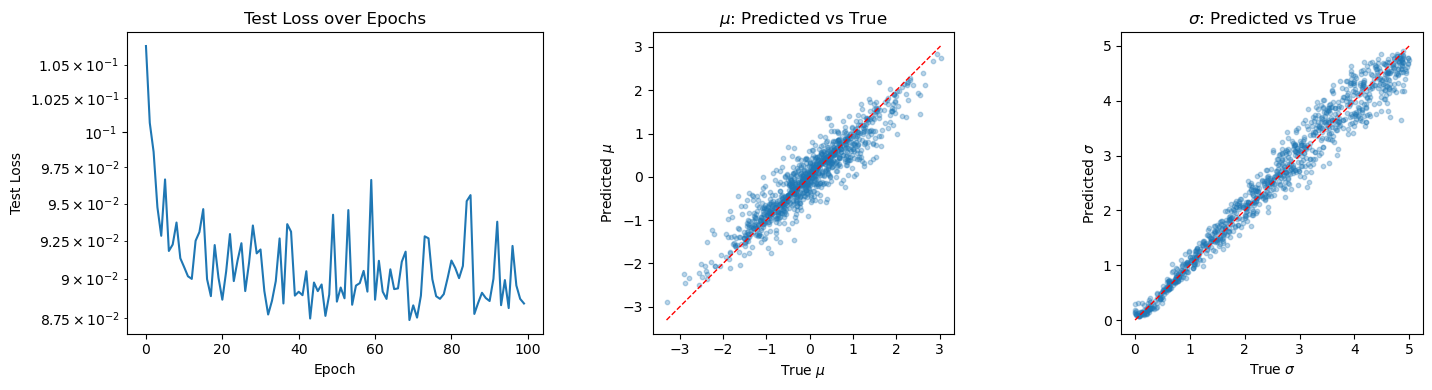

MSE: [0.12266567 0.0581851 ]


In [5]:
evaluate_model(posterior_normal_estimator, sample_batch, test_loss_history, [r'$\mu$', r'$\sigma$'])